# 🚁 NOTEBOOK 04: FEATURE ENGINEERING (PHYSICS ENHANCED)
**Project:** Intelligent Drone Flight Maneuver Recognition  
**Phase:** Feature Extraction  
**Update:** Bổ sung Kurtosis & Skewness để bắt tín hiệu va chạm (Impact) khi Landing.

## 🎯 Mục tiêu
1. **Input:** File Pickle `train_windows.pkl` (Mảng 3D: Samples x 100 x 6).
2. **Logic:** Trích xuất đặc trưng vật lý từ cửa sổ 1.0 giây.
   - **Time Domain:** Mean, Std, Min/Max.
   - **Impact Detection:** Kurtosis (Độ nhọn - bắt va chạm đùi), Skewness (Độ lệch).
   - **Frequency Domain (FFT):** Energy.
3. **Output:** File CSV 2D (`X_train.csv`, `y_train.csv`).

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
from tqdm import tqdm
from scipy.stats import linregress, kurtosis, skew

drive.mount('/content/drive')

# --- CẤU HÌNH ---
BASE_DIR = Path('/content/drive/MyDrive/Drone_Project_2025')
PROCESSED_DIR = BASE_DIR / 'data/processed'
FEATURES_DIR = BASE_DIR / 'data/features'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

SAMPLING_RATE = 100 # Hz

Mounted at /content/drive


## 🛠️ CORE LOGIC: FEATURE EXTRACTION

In [2]:
def extract_features_from_window(window_data):
    """
    Input: window_data (100, 6) -> [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]
    Output: Dictionary 1 dòng chứa các features
    """
    features = {}
    axis_names = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

    for i, axis in enumerate(axis_names):
        signal = window_data[:, i]

        # --- 1. TIME DOMAIN BASIC ---
        features[f'{axis}_mean'] = np.mean(signal)  # Tilt (Góc nghiêng)
        features[f'{axis}_std'] = np.std(signal)    # Vibration (Độ rung)
        features[f'{axis}_max'] = np.max(signal)    # Peak Positive
        features[f'{axis}_min'] = np.min(signal)    # Peak Negative
        features[f'{axis}_range'] = np.max(signal) - np.min(signal)
        features[f'{axis}_rms'] = np.sqrt(np.mean(signal**2))

        # --- 2. IMPACT & SHAPE (Bắt va chạm đùi) ---
        # Kurtosis: Độ nhọn. Landing va chạm -> Spike nhọn -> Kurtosis cao.
        features[f'{axis}_kurtosis'] = kurtosis(signal)

        # Skewness: Độ lệch. Takeoff (vụt lên) lệch dương, Landing (rơi xuống) lệch âm.
        features[f'{axis}_skew'] = skew(signal)

        # --- 3. 🔥 NEW: DYNAMICS & CHAOS (Để bắt Turbulence) ---

        # A. ZERO CROSSING RATE (ZCR)
        # Trừ đi trung bình để đưa tín hiệu về dao động quanh 0
        centered_signal = signal - np.mean(signal)
        # Đếm số lần đổi dấu (cắt qua trục hoành)
        # Takeoff: Thường chỉ cắt 1-2 lần (lên rồi xuống)
        # Turbulence: Cắt liên tục (>10 lần)
        zcr = ((centered_signal[:-1] * centered_signal[1:]) < 0).sum()
        features[f'{axis}_zcr'] = zcr

        # B. JERK (Độ giật - Đạo hàm của gia tốc)
        # Tính sự thay đổi giữa các mẫu liên tiếp
        # Turbulence lắc tay sẽ có độ thay đổi cực gắt
        jerk_signal = np.diff(signal)
        features[f'{axis}_jerk_mean'] = np.mean(np.abs(jerk_signal)) # Trung bình độ giật
        features[f'{axis}_jerk_max']  = np.max(np.abs(jerk_signal))  # Cú giật mạnh nhất

        # --- 4. FREQUENCY (FFT) ---
        fft_vals = np.abs(np.fft.rfft(signal))[1:]
        if len(fft_vals) > 0:
            features[f'{axis}_energy']   = np.sum(fft_vals**2) / len(fft_vals)
            features[f'{axis}_fft_max']  = np.max(fft_vals)
            # Dominant Frequency (Tần số trội)
            # Turbulence lắc tay thường có tần số cụ thể (VD: 3-5Hz)
            features[f'{axis}_dom_freq'] = np.argmax(fft_vals)
        else:
            features[f'{axis}_energy']   = 0
            features[f'{axis}_fft_max']  = 0
            features[f'{axis}_dom_freq'] = 0

    return features

In [3]:
def process_dataset(input_name, output_name):
    input_path = PROCESSED_DIR / f'{input_name}_windows.pkl'
    if not input_path.exists():
        print(f"⚠️ Không tìm thấy {input_name}. Bỏ qua.")
        return

    print(f"⚙️ Đang xử lý tập {input_name.upper()} (Extracting Kurtosis & Skewness)...")
    with open(input_path, 'rb') as f:
        data = pickle.load(f)

    X_windows = data['X']
    y_labels = data['y']

    feature_list = []
    for window in tqdm(X_windows, desc="Extracting"):
        feats = extract_features_from_window(window)
        feature_list.append(feats)

    # Lưu CSV
    X_df = pd.DataFrame(feature_list)
    y_df = pd.Series(y_labels, name='label')

    X_df.to_csv(FEATURES_DIR / f'X_{output_name}.csv', index=False)
    y_df.to_csv(FEATURES_DIR / f'y_{output_name}.csv', index=False)

    print(f"✅ Đã lưu {output_name}: {X_df.shape}")

In [4]:
# Chạy cho cả Train và Val
process_dataset('train', 'train')
process_dataset('val', 'val')

⚙️ Đang xử lý tập TRAIN (Extracting Kurtosis & Skewness)...


Extracting: 100%|██████████| 1750/1750 [00:16<00:00, 103.51it/s]


✅ Đã lưu train: (1750, 84)
⚙️ Đang xử lý tập VAL (Extracting Kurtosis & Skewness)...


Extracting: 100%|██████████| 130/130 [00:01<00:00, 112.18it/s]


✅ Đã lưu val: (130, 84)


## 🔎 KIỂM TRA ĐỘ NHỌN (KURTOSIS)
Xem liệu Kurtosis có giúp phân biệt được cú va chạm của Landing không.

/tmp/ipython-input-1560413497.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_viz, x='label', y='acc_z_kurtosis', showfliers=False, palette='Set2')


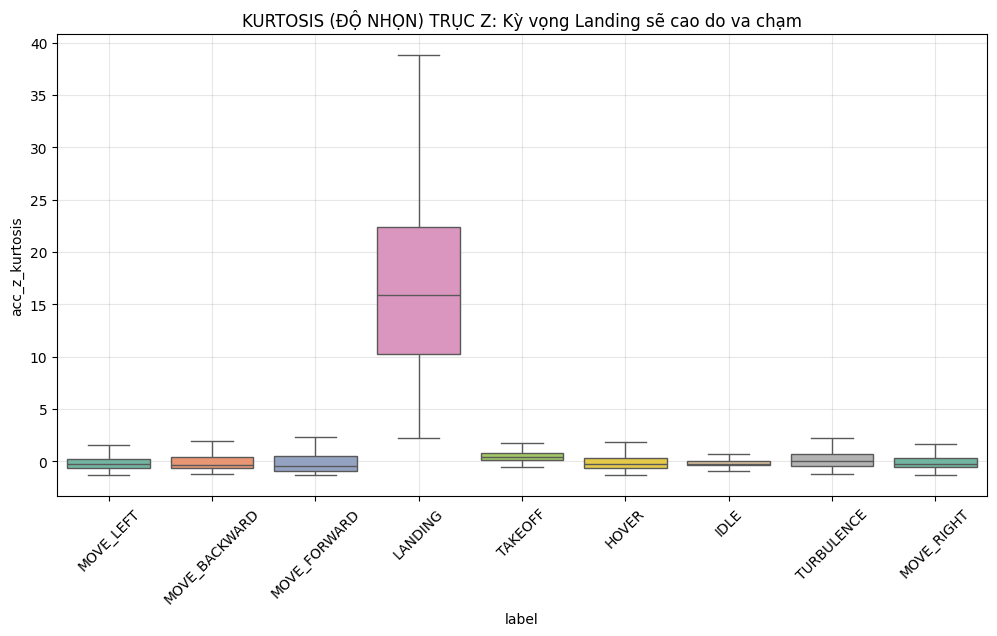

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

try:
    X_viz = pd.read_csv(FEATURES_DIR / 'X_train.csv')
    y_viz = pd.read_csv(FEATURES_DIR / 'y_train.csv')
    X_viz['label'] = y_viz['label']

    # Vẽ Boxplot so sánh Kurtosis trục Z
    plt.figure(figsize=(12, 6))
    plt.title("KURTOSIS (ĐỘ NHỌN) TRỤC Z: Kỳ vọng Landing sẽ cao do va chạm")
    sns.boxplot(data=X_viz, x='label', y='acc_z_kurtosis', showfliers=False, palette='Set2')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()
except Exception as e:
    print("Chưa vẽ được biểu đồ:", e)

---

/tmp/ipython-input-514628091.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='label', y='acc_z_kurtosis', ax=axes[0], palette='Set2', showfliers=False)
/tmp/ipython-input-514628091.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
/tmp/ipython-input-514628091.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='label', y='acc_z_zcr', ax=axes[1], palette='Set3', showfliers=False)
/tmp/ipython-input-514628091.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ti

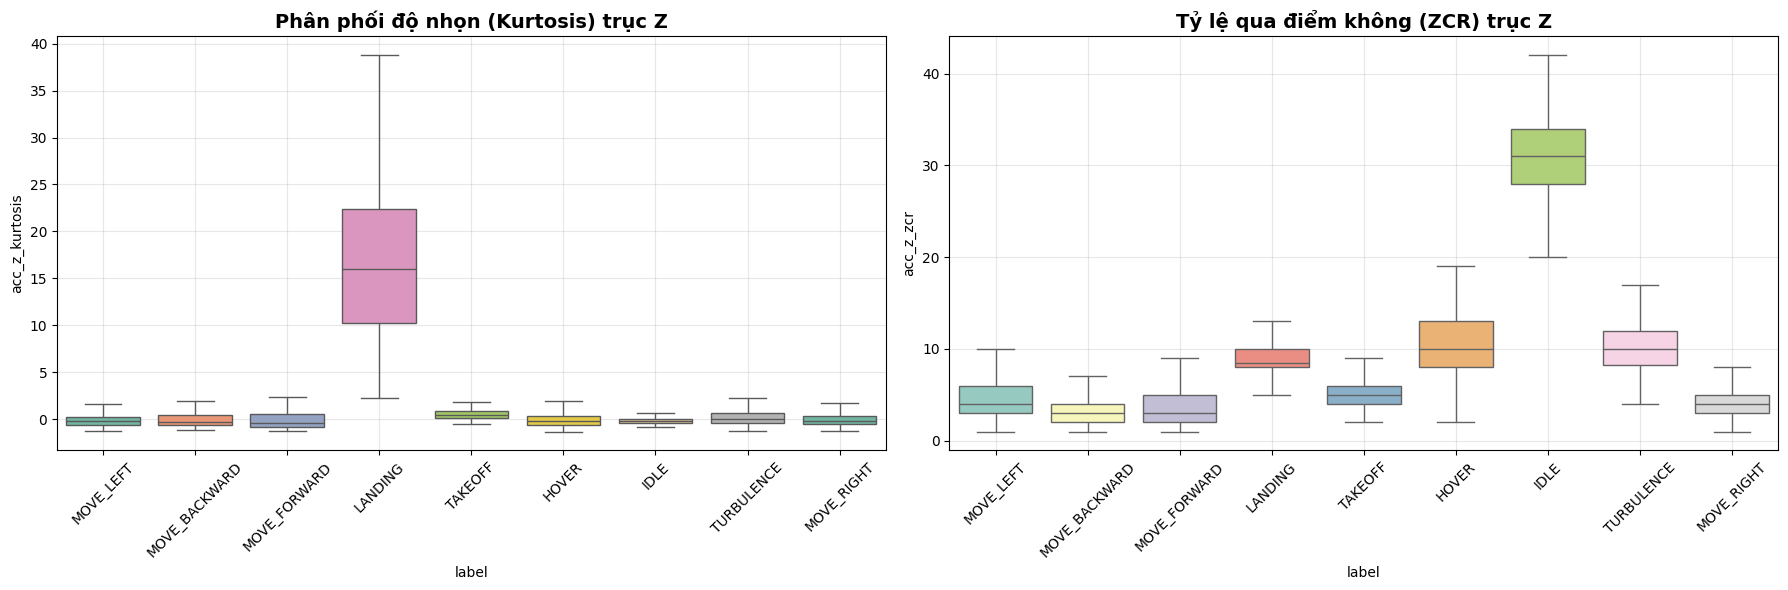

💡 Nhận xét: 'LANDING' có Kurtosis rất cao. 'TURBULENCE' có ZCR rất cao.


In [6]:
# --- VẼ BOXPLOT FEATURES ---
import seaborn as sns

def plot_feature_boxplots():
    # Load dữ liệu features đã tạo
    try:
        X_df = pd.read_csv(FEATURES_DIR / 'X_train.csv')
        y_df = pd.read_csv(FEATURES_DIR / 'y_train.csv')
        data = pd.concat([X_df, y_df], axis=1)

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        # 1. Kurtosis Z (Phân biệt Landing)
        sns.boxplot(data=data, x='label', y='acc_z_kurtosis', ax=axes[0], palette='Set2', showfliers=False)
        axes[0].set_title("Phân phối độ nhọn (Kurtosis) trục Z", fontsize=14, fontweight='bold')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
        axes[0].grid(True, alpha=0.3)

        # 2. ZCR Z (Phân biệt Turbulence)
        sns.boxplot(data=data, x='label', y='acc_z_zcr', ax=axes[1], palette='Set3', showfliers=False)
        axes[1].set_title("Tỷ lệ qua điểm không (ZCR) trục Z", fontsize=14, fontweight='bold')
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        print("💡 Nhận xét: 'LANDING' có Kurtosis rất cao. 'TURBULENCE' có ZCR rất cao.")

    except Exception as e:
        print(f"Chưa chạy xong Notebook 04 nên chưa có file CSV: {e}")

plot_feature_boxplots()